# Dataset link

https://www.data.gouv.fr/datasets/consommation-des-menages-par-fonction

# MetaData

| COD_VAR          | LIB_VAR                         | COD_MOD    | LIB_MOD                                                     |   GEO_OBJECT |
|:-----------------|:--------------------------------|:-----------|:------------------------------------------------------------|-------------:|
| ACCOUNTING_ENTRY | Account position                | D          | Use or debit                                                |          nan |
| ACCOUNTING_ENTRY | Account position                | _Z         | Not applicable                                              |          nan |
| ACCOUNTING_ENTRY | Account position                | C          | Resource or credit                                          |          nan |
| ACCOUNTING_ENTRY | Account position                | B          | Balance                                                     |          nan |
| ACTIVITY         | Economic activity               | _T         | Total                                                       |          nan |
| CONF_STATUS      | Confidentiality status          | F          | Public / Publishable                                        |          nan |
| COUNTERPART_AREA | Counterpart area                | W0         | World                                                       |          nan |
| COUNTERPART_AREA | Counterpart area                | W2         | National territory                                          |          nan |
| COUNTERPART_AREA | Counterpart area                | W1         | Rest of the word                                            |          nan |
| DECIMALS         | Decimals                        | 1          | One                                                         |          nan |
| DECIMALS         | Decimals                        | 3          | Three                                                       |          nan |
| EXPENDITURE      | Type of consumer expenditure    | _Z         | Total                                                       |          nan |
| EXPENDITURE      | Type of consumer expenditure    | CP1112     | Canteens, cafeterias and refectories (S)                    |          nan |
| EXPENDITURE      | Type of consumer expenditure    | CP04       | Housing, water, gas, electricity and other fuels            |          nan |
| EXPENDITURE      | Type of consumer expenditure    | CP121P_122 | Insurance (excluding life insurance) and financial services |          nan |

# Dataset Acquisition and Loading

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

In [127]:
df = pd.read_csv(
    "/kaggle/input/datasets/hugogascon/dd-cna-conso-menages-coicop/DD_CNA_CONSO_MENAGES_COICOP_data.csv",
    sep=';',
    engine="python",
    encoding="utf-8-sig"
)
df.head()

,ACCOUNTING_ENTRY,ACTIVITY,COUNTERPART_AREA,EXPENDITURE,FREQ,GEO,GEO_OBJECT,INSTR_ASSET,PRICES,PRODUCT,...,DECIMALS,LAST_UPDATE,OBS_STATUS,OBS_STATUS_FR,REF_PERIOD_DETAIL,REF_YEAR_PRICE,TABLE_IDENTIFIER,UNIT_MULT,TIME_PERIOD,OBS_VALUE
0,D,_T,W2,CP141,A,F,FRANCE,_Z,V,_T,...,1,NaN,M,D,NaN,NaN,NaN,6,2018,NaN
1,D,_T,W2,CP141,A,F,FRANCE,_Z,V,_T,...,1,NaN,M,D,NaN,NaN,NaN,6,2004,NaN
2,D,_T,W2,CP022,A,F,FRANCE,_Z,Y,_T,...,1,NaN,M,D,NaN,NaN,NaN,6,2010,NaN
3,D,_T,W2,CP141,A,F,FRANCE,_Z,Y,_T,...,1,NaN,M,D,NaN,NaN,NaN,6,1966,NaN
4,D,_T,W2,CP013,A,F,FRANCE,_Z,V,_T,...,1,NaN,L,D,NaN,NaN,NaN,6,1986,NaN


# Data Cleaning and Preparation

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258305 entries, 0 to 258304
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ACCOUNTING_ENTRY   258305 non-null  object 
 1   ACTIVITY           258305 non-null  object 
 2   COUNTERPART_AREA   258305 non-null  object 
 3   EXPENDITURE        258305 non-null  object 
 4   FREQ               258305 non-null  object 
 5   GEO                258305 non-null  object 
 6   GEO_OBJECT         258305 non-null  object 
 7   INSTR_ASSET        258305 non-null  object 
 8   PRICES             258305 non-null  object 
 9   PRODUCT            258305 non-null  object 
 10  REF_SECTOR         258305 non-null  object 
 11  STO                258305 non-null  object 
 12  TRANSFORMATION     258305 non-null  object 
 13  UNIT_MEASURE       258305 non-null  object 
 14  CONF_STATUS        258305 non-null  object 
 15  DECIMALS           258305 non-null  int64  
 16  LA

In [129]:
df.describe()

,DECIMALS,LAST_UPDATE,REF_PERIOD_DETAIL,REF_YEAR_PRICE,TABLE_IDENTIFIER,UNIT_MULT,TIME_PERIOD,OBS_VALUE
count,258305.000000,0.0,0.0,73356.0,0.0,258305.000000,258305.000000,2.575010e+05
mean,2.223414,NaN,NaN,2020.0,NaN,1.755715,1992.321267,1.033380e+04
std,0.974725,NaN,NaN,0.0,NaN,2.729796,19.183817,8.284712e+04
min,1.000000,NaN,NaN,2020.0,NaN,0.000000,1949.000000,-2.001100e+04
25%,1.000000,NaN,NaN,2020.0,NaN,0.000000,1976.000000,6.434000e+00
50%,3.000000,NaN,NaN,2020.0,NaN,0.000000,1992.000000,1.009040e+02
75%,3.000000,NaN,NaN,2020.0,NaN,6.000000,2009.000000,3.165000e+02
max,3.000000,NaN,NaN,2020.0,NaN,6.000000,2025.000000,2.991448e+06


In [130]:
df.isnull().sum()

ACCOUNTING_ENTRY          0
ACTIVITY                  0
COUNTERPART_AREA          0
EXPENDITURE               0
FREQ                      0
GEO                       0
GEO_OBJECT                0
INSTR_ASSET               0
PRICES                    0
PRODUCT                   0
REF_SECTOR                0
STO                       0
TRANSFORMATION            0
UNIT_MEASURE              0
CONF_STATUS               0
DECIMALS                  0
LAST_UPDATE          258305
OBS_STATUS                0
OBS_STATUS_FR             0
REF_PERIOD_DETAIL    258305
REF_YEAR_PRICE       184949
TABLE_IDENTIFIER     258305
UNIT_MULT                 0
TIME_PERIOD               0
OBS_VALUE               804
dtype: int64

In [131]:
(df['OBS_VALUE'] < 0).sum()

np.int64(12014)

In [132]:
negative_df = df[df['OBS_VALUE'] < 0]
print(negative_df[['ACCOUNTING_ENTRY', 'STO', 'EXPENDITURE', 'OBS_VALUE']].head(10))


print(negative_df['ACCOUNTING_ENTRY'].value_counts())

    ACCOUNTING_ENTRY  STO EXPENDITURE  OBS_VALUE
205                D  P31       CP012     -1.572
233                D  P31      CP0431     -1.415
282                D  P31      CP0312     -1.346
309                D  P31      CP0117     -0.960
319                D  P31       CP032     -1.027
466                D  P31       CP045     -4.086
469                D  P31      CP0451     -7.401
513                D  P31      CP0431     -8.096
546                D  P31      CP0454     -5.362
659                D  P31      CP0312    -16.626
ACCOUNTING_ENTRY
D    11987
C       26
B        1
Name: count, dtype: int64


In [133]:
df.loc[(df['OBS_VALUE'] < 0) | (df['OBS_VALUE'].isna()), 'OBS_VALUE'] = np.nan


df['OBS_VALUE'] = df.groupby('EXPENDITURE')['OBS_VALUE'].transform(lambda x: x.fillna(x.mean()))


df['OBS_VALUE'] = df['OBS_VALUE'].fillna(df['OBS_VALUE'].mean())


print(df['OBS_VALUE'].isna().sum())

0


In [134]:
df['OBS_VALUE'].unique()

array([1.05456979e+04, 7.89700800e+05, 2.63200000e+00, ...,
       7.18584400e+05, 2.70517400e+05, 1.42882000e+04])

In [135]:
print(df.dtypes)

ACCOUNTING_ENTRY      object
ACTIVITY              object
COUNTERPART_AREA      object
EXPENDITURE           object
FREQ                  object
GEO                   object
GEO_OBJECT            object
INSTR_ASSET           object
PRICES                object
PRODUCT               object
REF_SECTOR            object
STO                   object
TRANSFORMATION        object
UNIT_MEASURE          object
CONF_STATUS           object
DECIMALS               int64
LAST_UPDATE          float64
OBS_STATUS            object
OBS_STATUS_FR         object
REF_PERIOD_DETAIL    float64
REF_YEAR_PRICE       float64
TABLE_IDENTIFIER     float64
UNIT_MULT              int64
TIME_PERIOD            int64
OBS_VALUE            float64
dtype: object


In [136]:
print(df[df['OBS_VALUE'] > 3095.01][['ACTIVITY', 'OBS_VALUE']].head(20))

   ACTIVITY     OBS_VALUE
0        _T  10545.697942
1        _T  10545.697942
2        _T  10545.697942
3        _T  10545.697942
4        _T  10545.697942
5        _T  10545.697942
6        _T  10545.697942
7        _T  10545.697942
8        _T  10545.697942
9        _T  10545.697942
10       _T  10545.697942
11       _T  10545.697942
12       _T  10545.697942
13       _T  10545.697942
14       _T  10545.697942
15       _T  10545.697942
16       _T  10545.697942
17       _T  10545.697942
18       _T  10545.697942
19       _T  10545.697942


# Descriptive Statistics

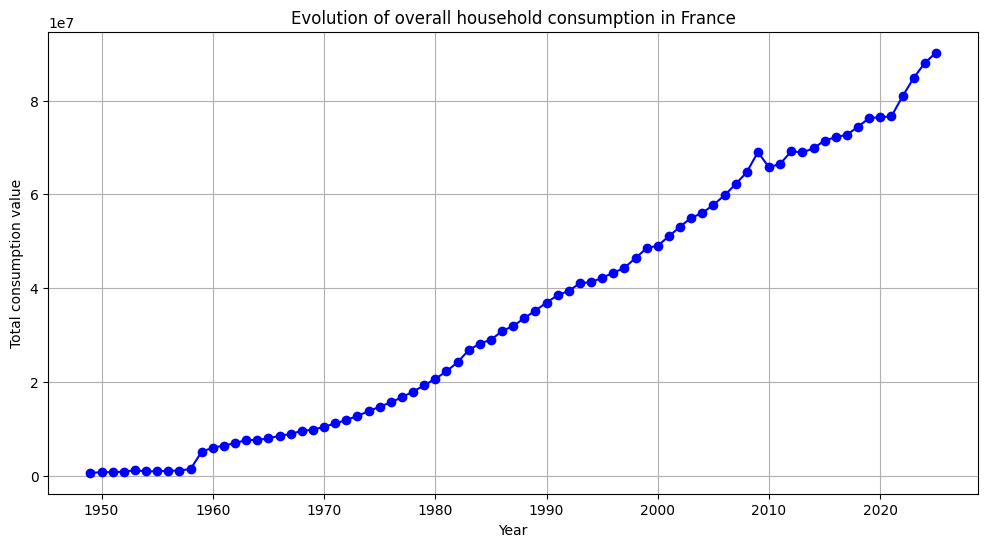

In [137]:
df_time = df.groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(df_time['TIME_PERIOD'], df_time['OBS_VALUE'], marker='o', linestyle='-', color='b')
plt.title("Evolution of overall household consumption in France")
plt.xlabel("Year")
plt.ylabel("Total consumption value")
plt.grid(True)
plt.show()

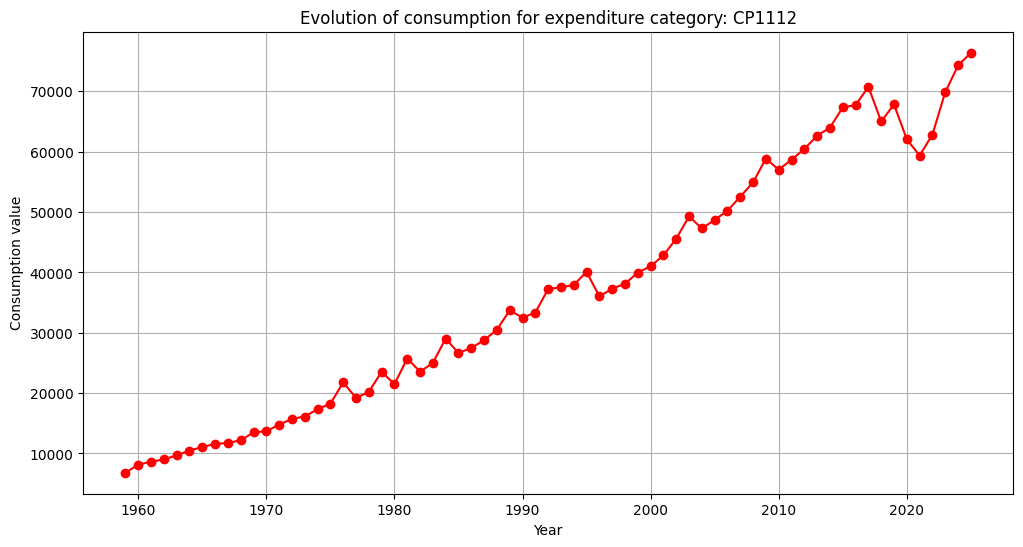

In [138]:
target_code = 'CP1112'

df_sector = df[(df['EXPENDITURE'] == target_code) & (df['GEO_OBJECT'] == 'FRANCE')]

df_sector_time = df_sector.groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(df_sector_time['TIME_PERIOD'], df_sector_time['OBS_VALUE'], marker='o', color='red')
plt.title(f"Evolution of consumption for expenditure category: {target_code}")
plt.xlabel("Year")
plt.ylabel("Consumption value")
plt.grid(True)
plt.show()

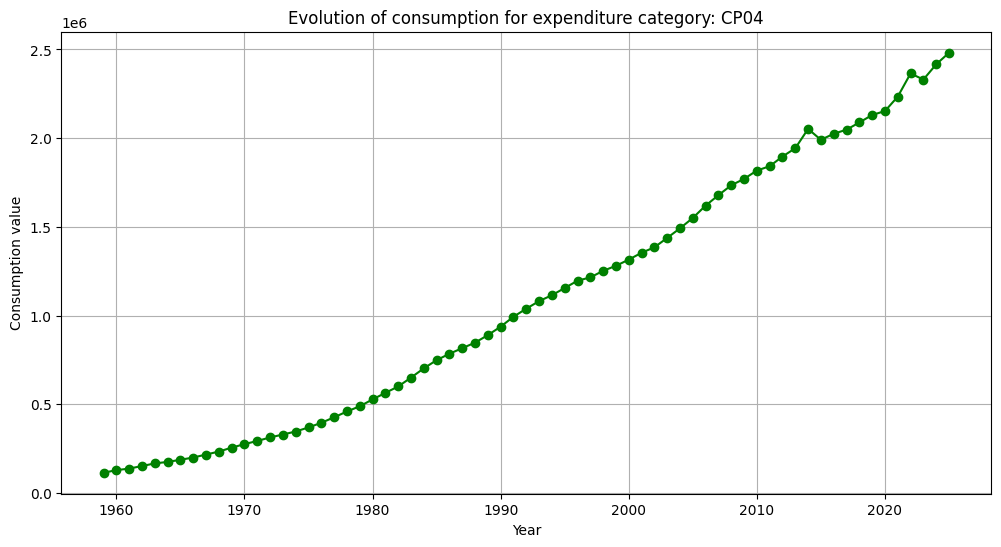

In [139]:
target_code = 'CP04'

df_sector = df[(df['EXPENDITURE'] == target_code) & (df['GEO_OBJECT'] == 'FRANCE')]

df_sector_time = df_sector.groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(df_sector_time['TIME_PERIOD'], df_sector_time['OBS_VALUE'], marker='o', color='green')
plt.title(f"Evolution of consumption for expenditure category: {target_code}")
plt.xlabel("Year")
plt.ylabel("Consumption value")
plt.grid(True)
plt.show()

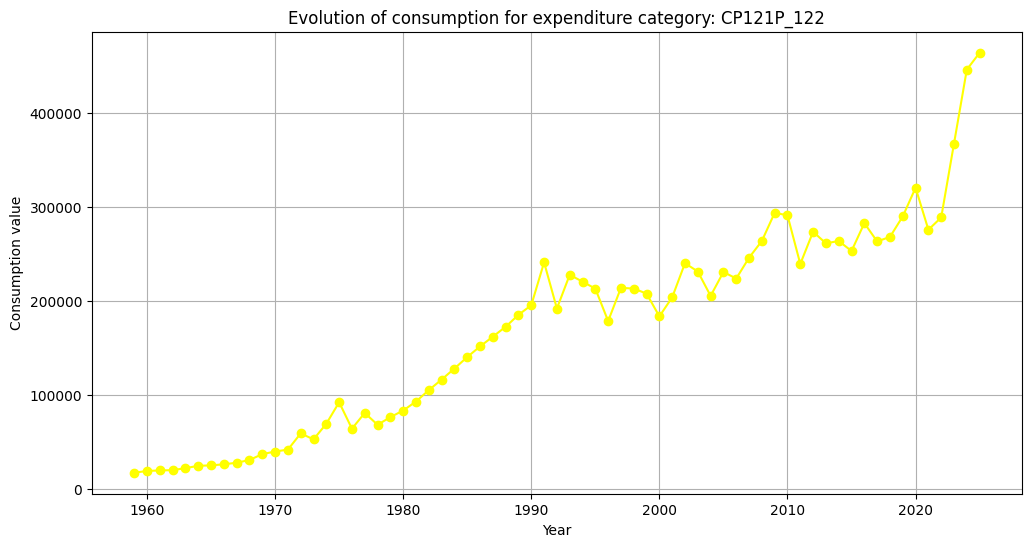

In [140]:
target_code = 'CP121P_122'

df_sector = df[(df['EXPENDITURE'] == target_code) & (df['GEO_OBJECT'] == 'FRANCE')]

df_sector_time = df_sector.groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(df_sector_time['TIME_PERIOD'], df_sector_time['OBS_VALUE'], marker='o', color='yellow')
plt.title(f"Evolution of consumption for expenditure category: {target_code}")
plt.xlabel("Year")
plt.ylabel("Consumption value")
plt.grid(True)
plt.show()

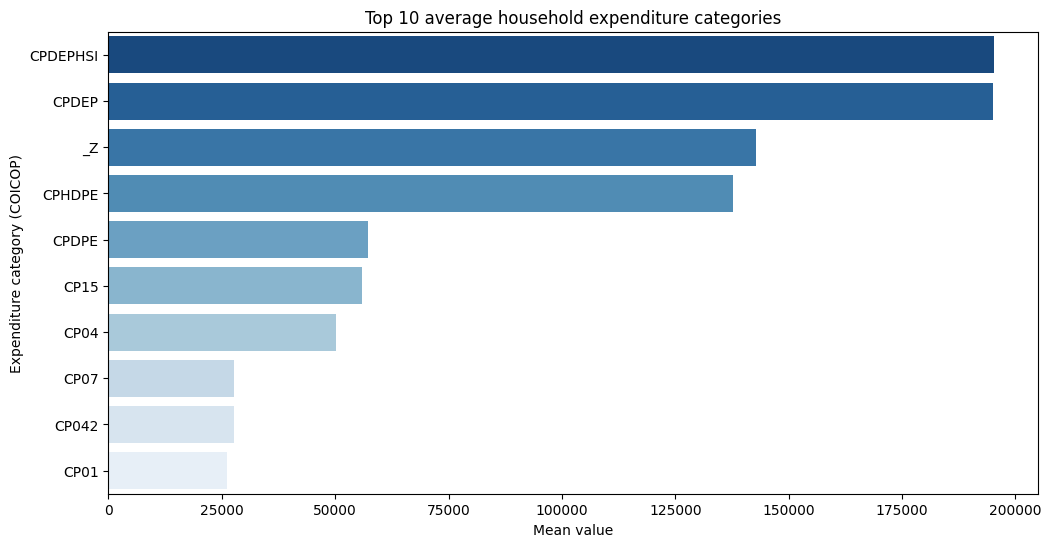

In [141]:
top_exp = df.groupby('EXPENDITURE')['OBS_VALUE'].mean().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_exp, x='OBS_VALUE', y='EXPENDITURE', hue='EXPENDITURE', palette='Blues_r', legend=False)
plt.title("Top 10 average household expenditure categories")
plt.xlabel("Mean value")
plt.ylabel("Expenditure category (COICOP)")
plt.show()

# Inferential Statistics

In [142]:
consumption_series = df.groupby('TIME_PERIOD')['OBS_VALUE'].sum().dropna()

adf_result = adfuller(consumption_series)

print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
if adf_result[1] < 0.05:
    print("The series is stationary (no unit root).")
else:
    print("The series is not stationary (presence of a trend).")

ADF Statistic: 3.462663280395704
p-value: 1.0
The series is not stationary (presence of a trend).


In [143]:
differenced_series = consumption_series.diff().dropna()

adf_result_diff = adfuller(differenced_series)

print(f"ADF Statistic (differenced): {adf_result_diff[0]}")
print(f"p-value (differenced): {adf_result_diff[1]}")

if adf_result_diff[1] < 0.05:
    print("The differenced series is stationary! It's perfect for modeling variations.")

ADF Statistic (differenced): -3.1337975555848656
p-value (differenced): 0.024151035513205944
The differenced series is stationary! It's perfect for modeling variations.


In [144]:
X = sm.add_constant(serie_conso.index)
y = serie_conso.values

modele = sm.OLS(y, X).fit()

print(modele.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     2932.
Date:                Sat, 05 Sep 2026   Prob (F-statistic):           7.14e-62
Time:                        23:30:49   Log-Likelihood:                -1285.8
No. Observations:                  77   AIC:                             2576.
Df Residuals:                      75   BIC:                             2580.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.382e+09   4.47e+07    -53.351      0.0